**Retail Sales Intelligence & Customer Behavior Analytics**

**1. Import Libraries**

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sqlalchemy import create_engine

**2. Load Dataset**

In [89]:
df = pd.read_csv("customer_purchase_behavior.csv")

In [90]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [91]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


**3. Initial Exploration**

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [93]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [94]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

**4. Data Cleaning**

In [9]:
# Imputing missing values in Review Rating column with the median rating of the product category
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [10]:
df.columns = df.columns.str.lower()

In [11]:
df.columns = df.columns.str.replace(" ", "_")

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_(usd)     0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [14]:
# Renaming columns according to snake casing for better readability and documentation
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [15]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

**5. Feature Engineering**

In [16]:
# create a new column age_group
bins = [0, 18, 25, 35, 50, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Mid Age', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [17]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Senior
1,19,Young Adult
2,50,Mid Age
3,21,Young Adult
4,45,Mid Age
5,46,Mid Age
6,63,Senior
7,27,Adult
8,26,Adult
9,57,Senior


In [18]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [19]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [20]:
# create new column Customer_Segment and Drop Promo_Code_used
def segment(x):
    if x <= 2:
        return 'New'
    elif x <= 5:
        return 'Returning'
    else:
        return 'Loyal'

df['customer_segment'] = df['previous_purchases'].apply(segment)

if 'promo_code_used' in df.columns:
    df.drop(columns=['promo_code_used'], inplace=True)

In [21]:
df['revenue'] = df['purchase_amount']

In [22]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days',
       'customer_segment', 'revenue'],
      dtype='str')

**6. Export Data**

In [27]:
# df.to_csv("cleaned_retail_data.csv", index=False)

In [23]:
# Install dependencies (run once in terminal, not notebook ideally)
# pip install pymysql sqlalchemy

import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

# MySQL credentials
username = "root"
password = urllib.parse.quote_plus("Mysql@2026")
host = "127.0.0.1"
port = "3306"
database = "Retail_Sales"

# Create engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Test connection
try:
    with engine.connect() as conn:
        print("✅ Connection successful!")
except Exception as e:
    print("❌ Connection failed:", e)

# Write DataFrame to MySQL
table_name = "customers"
df.to_sql(table_name, con=engine, if_exists="replace", index=False)

# Read data back
result = pd.read_sql(f"SELECT * FROM {table_name};", con=engine)
print(result)

✅ Connection successful!
      customer_id  age  gender item_purchased     category  purchase_amount  \
0               1   55    Male         Blouse     Clothing               53   
1               2   19    Male        Sweater     Clothing               64   
2               3   50    Male          Jeans     Clothing               73   
3               4   21    Male        Sandals     Footwear               90   
4               5   45    Male         Blouse     Clothing               49   
...           ...  ...     ...            ...          ...              ...   
3895         3896   40  Female         Hoodie     Clothing               28   
3896         3897   52  Female       Backpack  Accessories               49   
3897         3898   46  Female           Belt  Accessories               33   
3898         3899   44  Female          Shoes     Footwear               77   
3899         3900   52  Female        Handbag  Accessories               81   

           location size  

## 7. EDA Visualizations

**7.1 Customer Analysis**

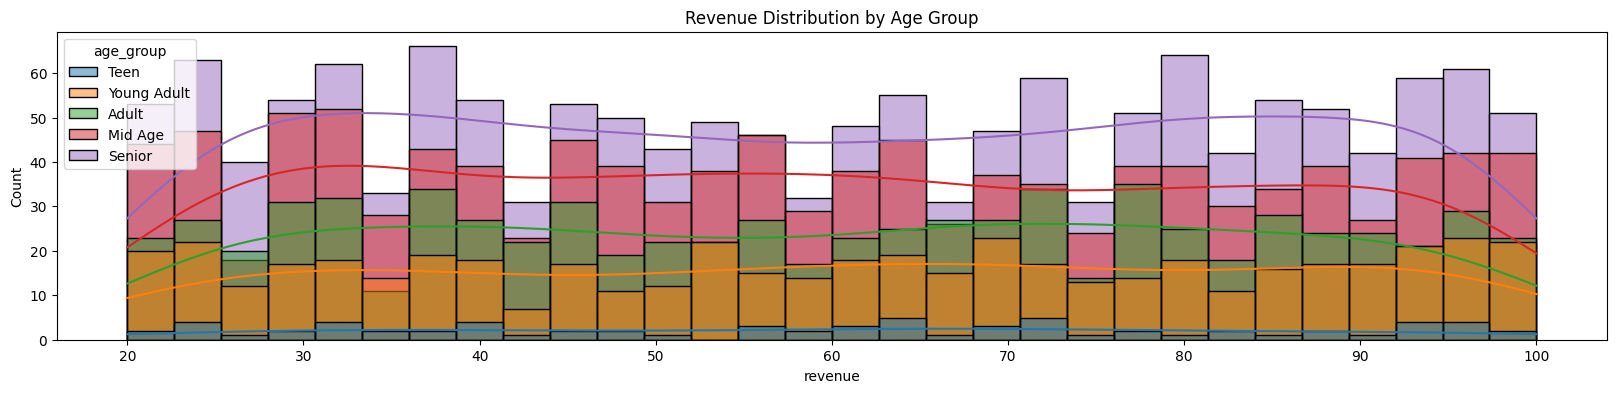

In [86]:
# Revenue Distribution Across Customer Age Groups
plt.figure(figsize=(20,4))
sns.histplot(data=df, x='revenue', hue='age_group', bins=30, kde=True)
plt.title("Revenue Distribution by Age Group")
plt.show()

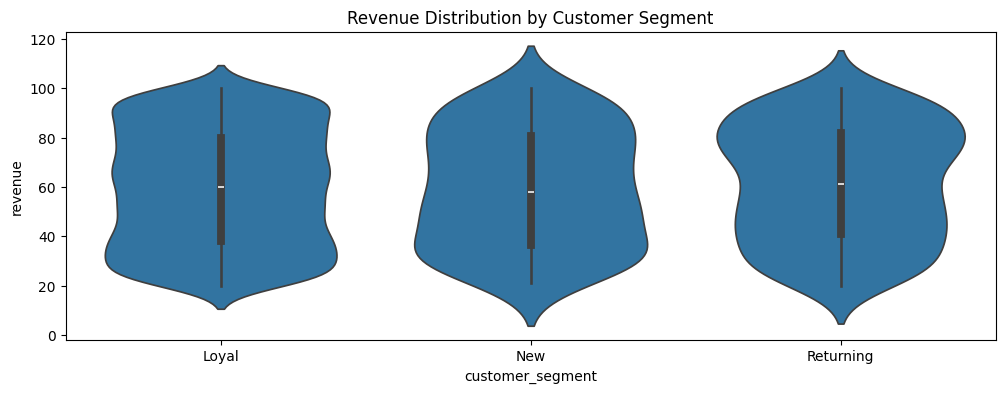

In [45]:
# Revenue Distribution by Customer Segments
plt.figure(figsize=(12,4))
sns.violinplot(x='customer_segment', y='revenue', data=df)
plt.title("Revenue Distribution by Customer Segment")
plt.show()

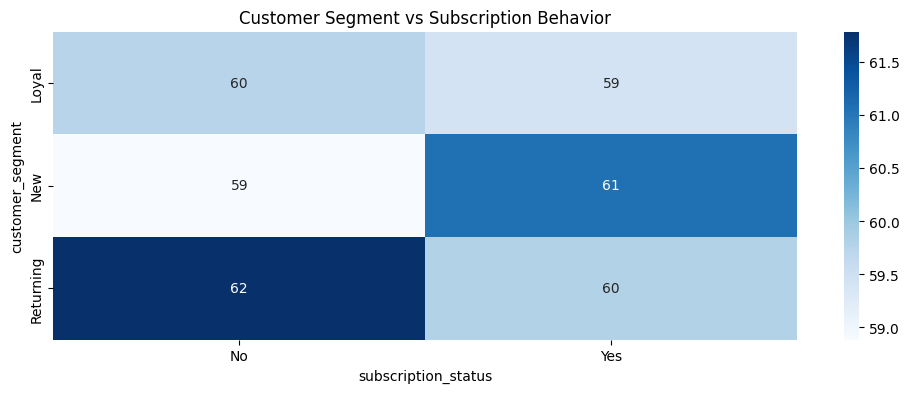

In [44]:
# Impact of Subscription Status on Customer Revenue by Segment
pivot = df.pivot_table(values='revenue',
                       index='customer_segment',
                       columns='subscription_status',
                       aggfunc='mean')
plt.figure(figsize=(12,4))
sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("Customer Segment vs Subscription Behavior")
plt.show()

**7.2 Product & Category Analysis**

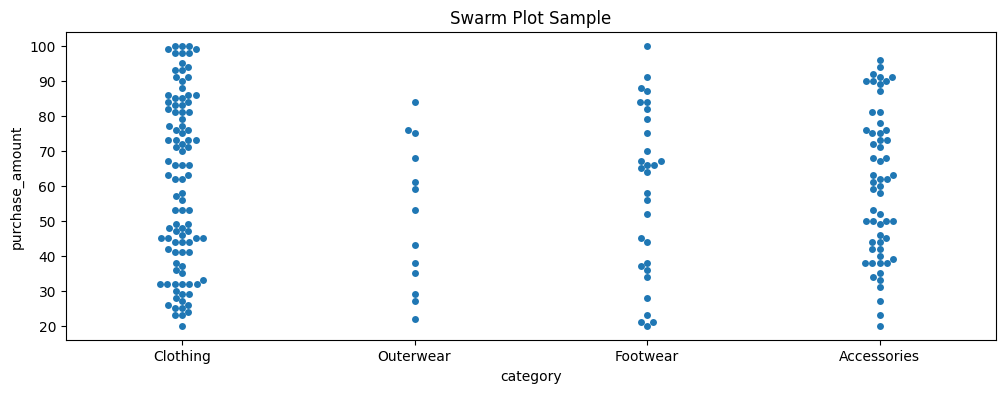

In [43]:
# Purchase Amount Distribution Across Product Categories
sample_df = df.sample(200)
plt.figure(figsize=(12,4))
sns.swarmplot(data=sample_df, x="category", y="purchase_amount", size=5)
plt.title("Swarm Plot Sample")
plt.show()

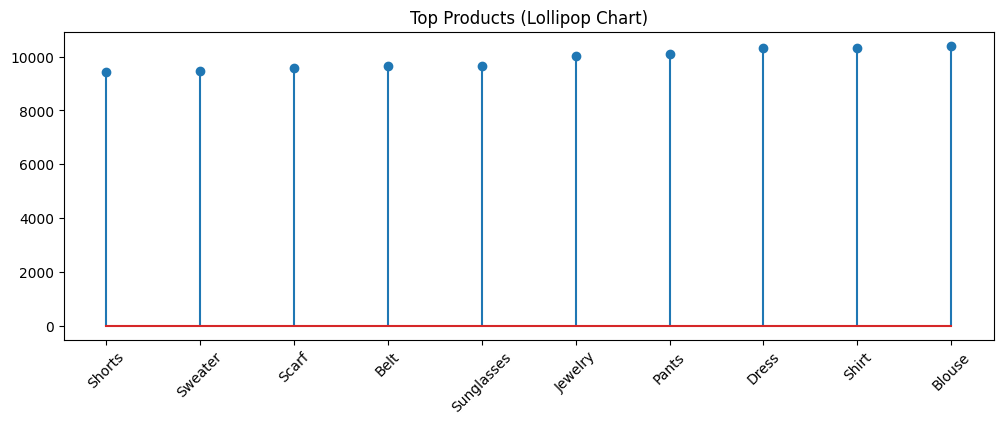

In [42]:
# Top 10 Revenue-Generating Products
top = df.groupby('item_purchased')['revenue'].sum().sort_values().tail(10)
plt.figure(figsize=(12,4))
plt.stem(top.index, top.values)
plt.xticks(rotation=45)
plt.title("Top Products (Lollipop Chart)")
plt.show()

**7.3 Pricing & Discount Analysis**

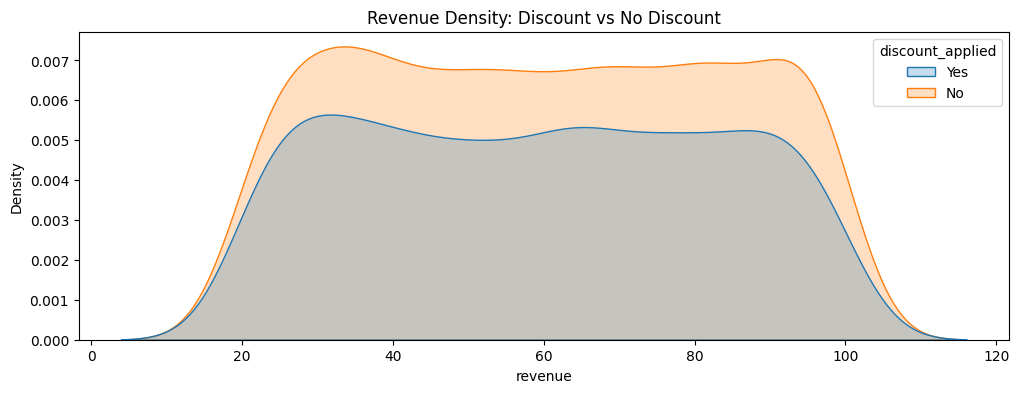

In [47]:
# Revenue Distribution: Discount vs Non-Discount Transactions
plt.figure(figsize=(12,4))
sns.kdeplot(data=df, x='revenue', hue='discount_applied', fill=True)
plt.title("Revenue Density: Discount vs No Discount")
plt.show()

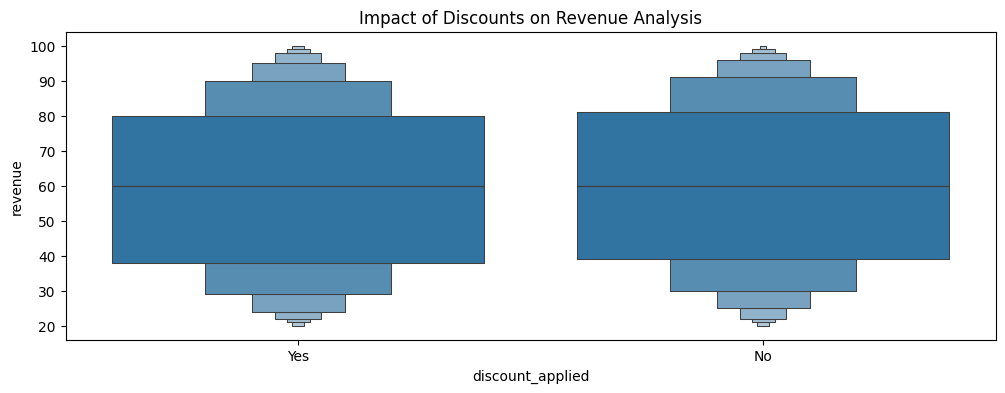

In [48]:
# Impact of Discounts on Revenue Distribution
plt.figure(figsize=(12,4))
sns.boxenplot(data=df, x='discount_applied', y='revenue')
plt.title("Impact of Discounts on Revenue Analysis")
plt.show()

**7.4 Sales & Time-Based Trends**

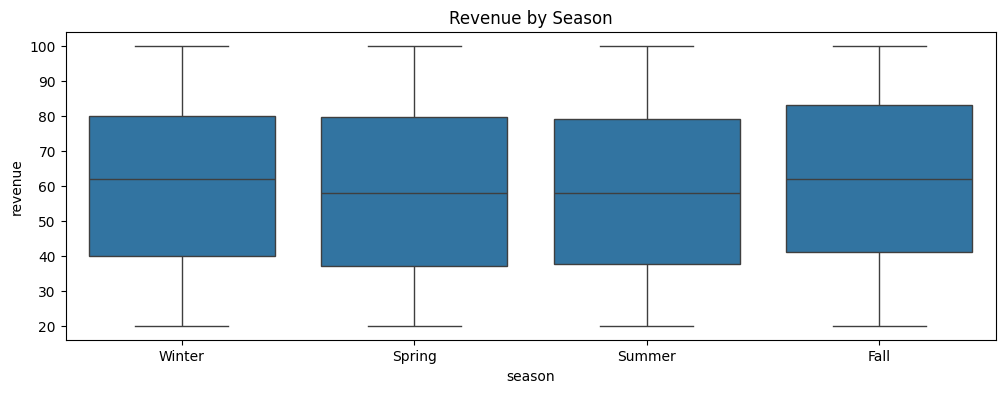

In [29]:
# Seasonal Trends in Revenue Performance
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x="season", y="revenue")
plt.title("Revenue by Season")
plt.show()

**7.5 Customer Experience Analysis**

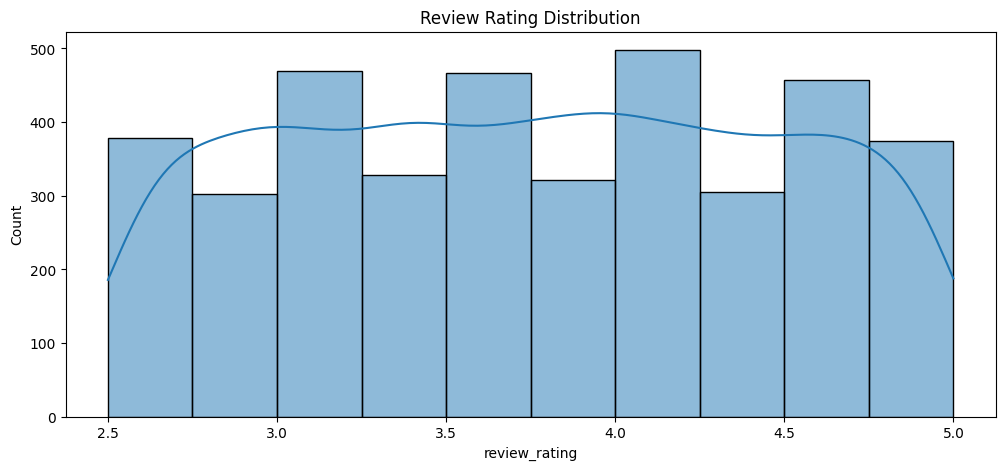

In [31]:
# Distribution of Customer Review Ratings
plt.figure(figsize=(12,5))
sns.histplot(df["review_rating"], bins=10, kde=True)
plt.title("Review Rating Distribution")
plt.show()

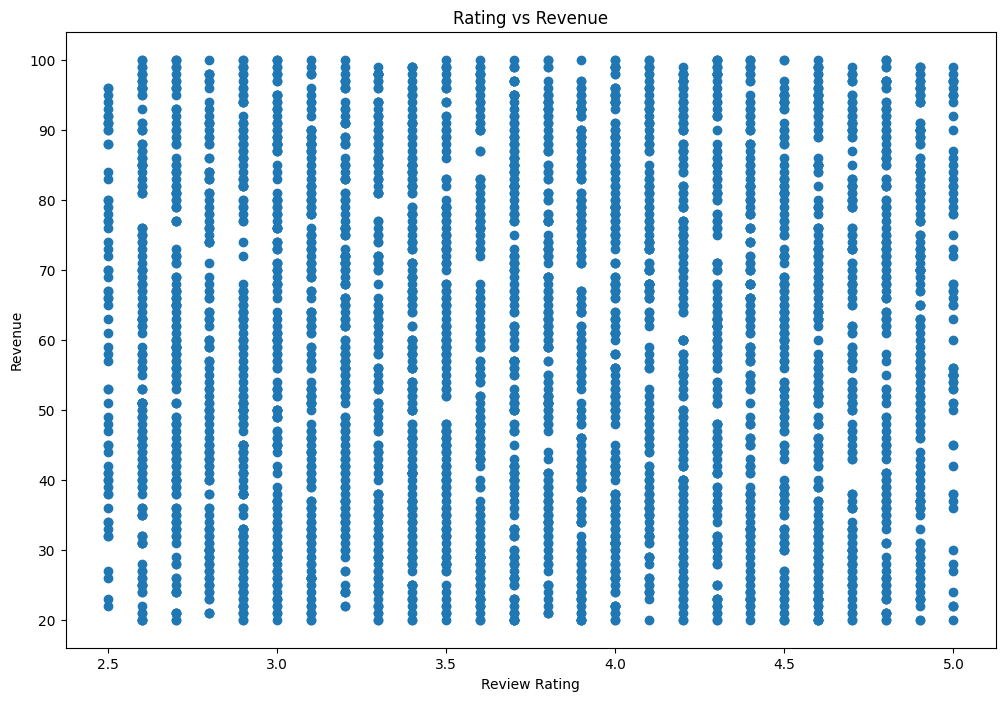

In [32]:
# Relationship Between Customer Ratings and Revenue
plt.figure(figsize=(12,8))
plt.scatter(df['review_rating'], df['revenue'])
plt.title("Rating vs Revenue")
plt.xlabel("Review Rating")
plt.ylabel("Revenue")
plt.show()

**7.6 Correlation & Statistical Analysis**

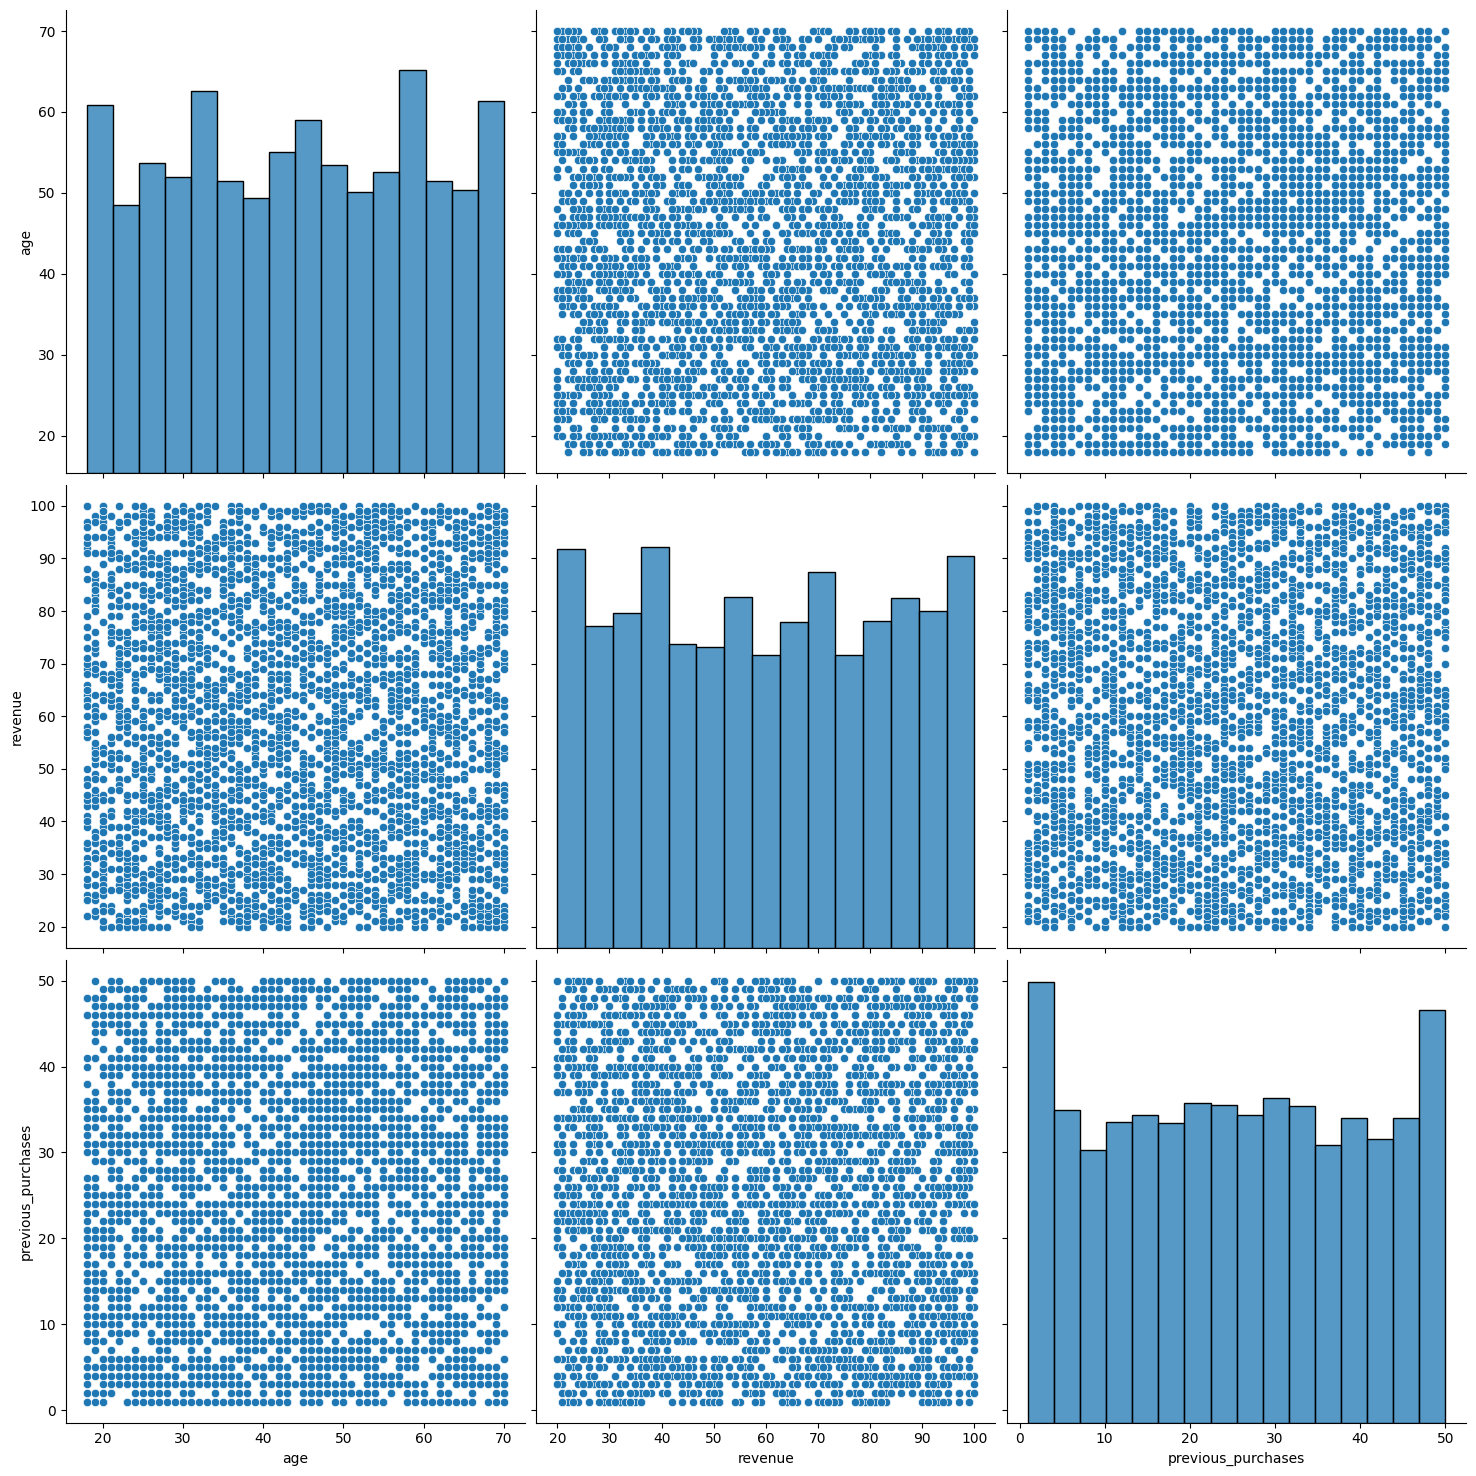

In [23]:
# Correlation & Relationship Analysis Among Key Variables
sns.pairplot(df[['age','revenue','previous_purchases']], height=5)
plt.show()

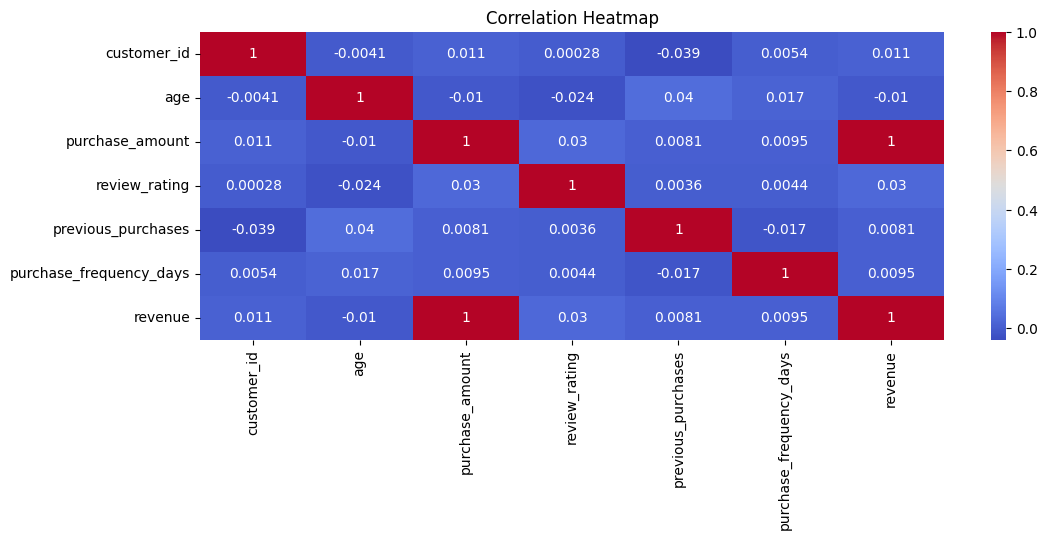

In [87]:
# Correlation Matrix of Key Numerical Features
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Key Insights**

In [28]:
print("Total Revenue:", df['revenue'].sum())
print("Average Revenue:", df['revenue'].mean())

print("\nTop Category:")
print(df.groupby('category')['revenue'].sum().sort_values(ascending=False).head(1))

print("\nTop Age Group:")
print(df.groupby('age_group')['revenue'].sum().sort_values(ascending=False).head(1))

print("\nSubscription Impact:")
print(df.groupby('subscription_status')['revenue'].mean())

Total Revenue: 233081
Average Revenue: 59.76435897435898

Top Category:
category
Clothing    104264
Name: revenue, dtype: int64

Top Age Group:
age_group
Senior    88480
Name: revenue, dtype: int64

Subscription Impact:
subscription_status
No     59.865121
Yes    59.491928
Name: revenue, dtype: float64


## 9. Save Final Dataset for Power BI

In [34]:
# df.to_csv("final_dashboard_data.csv", index=False)